In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
from sklearn.datasets import load_diabetes  #hazır veri tabanlarından birini kullanmak istedim
data = load_diabetes()  #isim değiştirdim

df = pd.DataFrame(data.data, columns=data.feature_names)  #data frame olarak kayıtlı olmadığından data frame çevirdim

df['target'] = data.target

print(df.head(10))

       age      sex      bmi       bp       s1       s2       s3       s4  \
0  0.03808  0.05068  0.06170  0.02187 -0.04422 -0.03482 -0.04340 -0.00259   
1 -0.00188 -0.04464 -0.05147 -0.02633 -0.00845 -0.01916  0.07441 -0.03949   
2  0.08530  0.05068  0.04445 -0.00567 -0.04560 -0.03419 -0.03236 -0.00259   
3 -0.08906 -0.04464 -0.01160 -0.03666  0.01219  0.02499 -0.03604  0.03431   
4  0.00538 -0.04464 -0.03638  0.02187  0.00393  0.01560  0.00814 -0.00259   
5 -0.09270 -0.04464 -0.04070 -0.01944 -0.06899 -0.07929  0.04128 -0.07639   
6 -0.04547  0.05068 -0.04716 -0.01600 -0.04010 -0.02480  0.00078 -0.03949   
7  0.06350  0.05068 -0.00189  0.06663  0.09062  0.10891  0.02287  0.01770   
8  0.04171  0.05068  0.06170 -0.04010 -0.01395  0.00620 -0.02867 -0.00259   
9 -0.07090 -0.04464  0.03906 -0.03321 -0.01258 -0.03451 -0.02499 -0.00259   

        s5       s6    target  
0  0.01991 -0.01765 151.00000  
1 -0.06833 -0.09220  75.00000  
2  0.00286 -0.02593 141.00000  
3  0.02269 -0.00936 206.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [10]:
print(df.describe().T)

        count          mean        std        min        25%         50%  \
age     442.0 -2.511817e-19   0.047619  -0.107226  -0.037299    0.005383   
sex     442.0  1.230790e-17   0.047619  -0.044642  -0.044642   -0.044642   
bmi     442.0 -2.245564e-16   0.047619  -0.090275  -0.034229   -0.007284   
bp      442.0 -4.797570e-17   0.047619  -0.112399  -0.036656   -0.005670   
s1      442.0 -1.381499e-17   0.047619  -0.126781  -0.034248   -0.004321   
s2      442.0  3.918434e-17   0.047619  -0.115613  -0.030358   -0.003819   
s3      442.0 -5.777179e-18   0.047619  -0.102307  -0.035117   -0.006584   
s4      442.0 -9.042540e-18   0.047619  -0.076395  -0.039493   -0.002592   
s5      442.0  9.293722e-17   0.047619  -0.126097  -0.033246   -0.001947   
s6      442.0  1.130318e-17   0.047619  -0.137767  -0.033179   -0.001078   
target  442.0  1.521335e+02  77.093005  25.000000  87.000000  140.500000   

               75%         max  
age       0.038076    0.110727  
sex       0.050680   

In [13]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)  #sayı yapılarını üssel gösterimden virgül sonrası 5 basamağa rast gelecek şekilde ayarladık
df.describe().T   #aşağıdaki tabloda verinin önceden scale edildiği anlaşılıyor

,count,mean,std,min,25%,50%,75%,max
age,442.00000,-0.00000,0.04762,-0.10723,-0.03730,0.00538,0.03808,0.11073
sex,442.00000,0.00000,0.04762,-0.04464,-0.04464,-0.04464,0.05068,0.05068
bmi,442.00000,-0.00000,0.04762,-0.09028,-0.03423,-0.00728,0.03125,0.17056
bp,442.00000,-0.00000,0.04762,-0.11240,-0.03666,-0.00567,0.03564,0.13204
s1,442.00000,-0.00000,0.04762,-0.12678,-0.03425,-0.00432,0.02836,0.15391
s2,442.00000,0.00000,0.04762,-0.11561,-0.03036,-0.00382,0.02984,0.19879
s3,442.00000,-0.00000,0.04762,-0.10231,-0.03512,-0.00658,0.02931,0.18118
s4,442.00000,-0.00000,0.04762,-0.07639,-0.03949,-0.00259,0.03431,0.18523
s5,442.00000,0.00000,0.04762,-0.12610,-0.03325,-0.00195,0.03243,0.13360
s6,442.00000,0.00000,0.04762,-0.13777,-0.03318,-0.00108,0.02792,0.13561


In [14]:
df.isnull().sum()  #eksik veri vaarsa sayısı işlenmiş veri olduğundan yok

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [15]:
#Veri setinde sutun ismi değiştirme
yeni_isimler = {'s1': 'total_chol', 's2': 'ldl', 's3': 'hdl', 
    's4': 'tch_hdl_ratio', 's5': 'triglycerides', 's6': 'glucose'} #isimleri belirledik
df.rename(columns=yeni_isimler, inplace=True) #rename ile yeni isimler sutun üzerinde değiştirildi
print(df.head())

       age      sex      bmi       bp  total_chol      ldl      hdl  \
0  0.03808  0.05068  0.06170  0.02187    -0.04422 -0.03482 -0.04340   
1 -0.00188 -0.04464 -0.05147 -0.02633    -0.00845 -0.01916  0.07441   
2  0.08530  0.05068  0.04445 -0.00567    -0.04560 -0.03419 -0.03236   
3 -0.08906 -0.04464 -0.01160 -0.03666     0.01219  0.02499 -0.03604   
4  0.00538 -0.04464 -0.03638  0.02187     0.00393  0.01560  0.00814   

   tch_hdl_ratio  triglycerides  glucose    target  
0       -0.00259        0.01991 -0.01765 151.00000  
1       -0.03949       -0.06833 -0.09220  75.00000  
2       -0.00259        0.00286 -0.02593 141.00000  
3        0.03431        0.02269 -0.00936 206.00000  
4       -0.00259       -0.03199 -0.04664 135.00000  


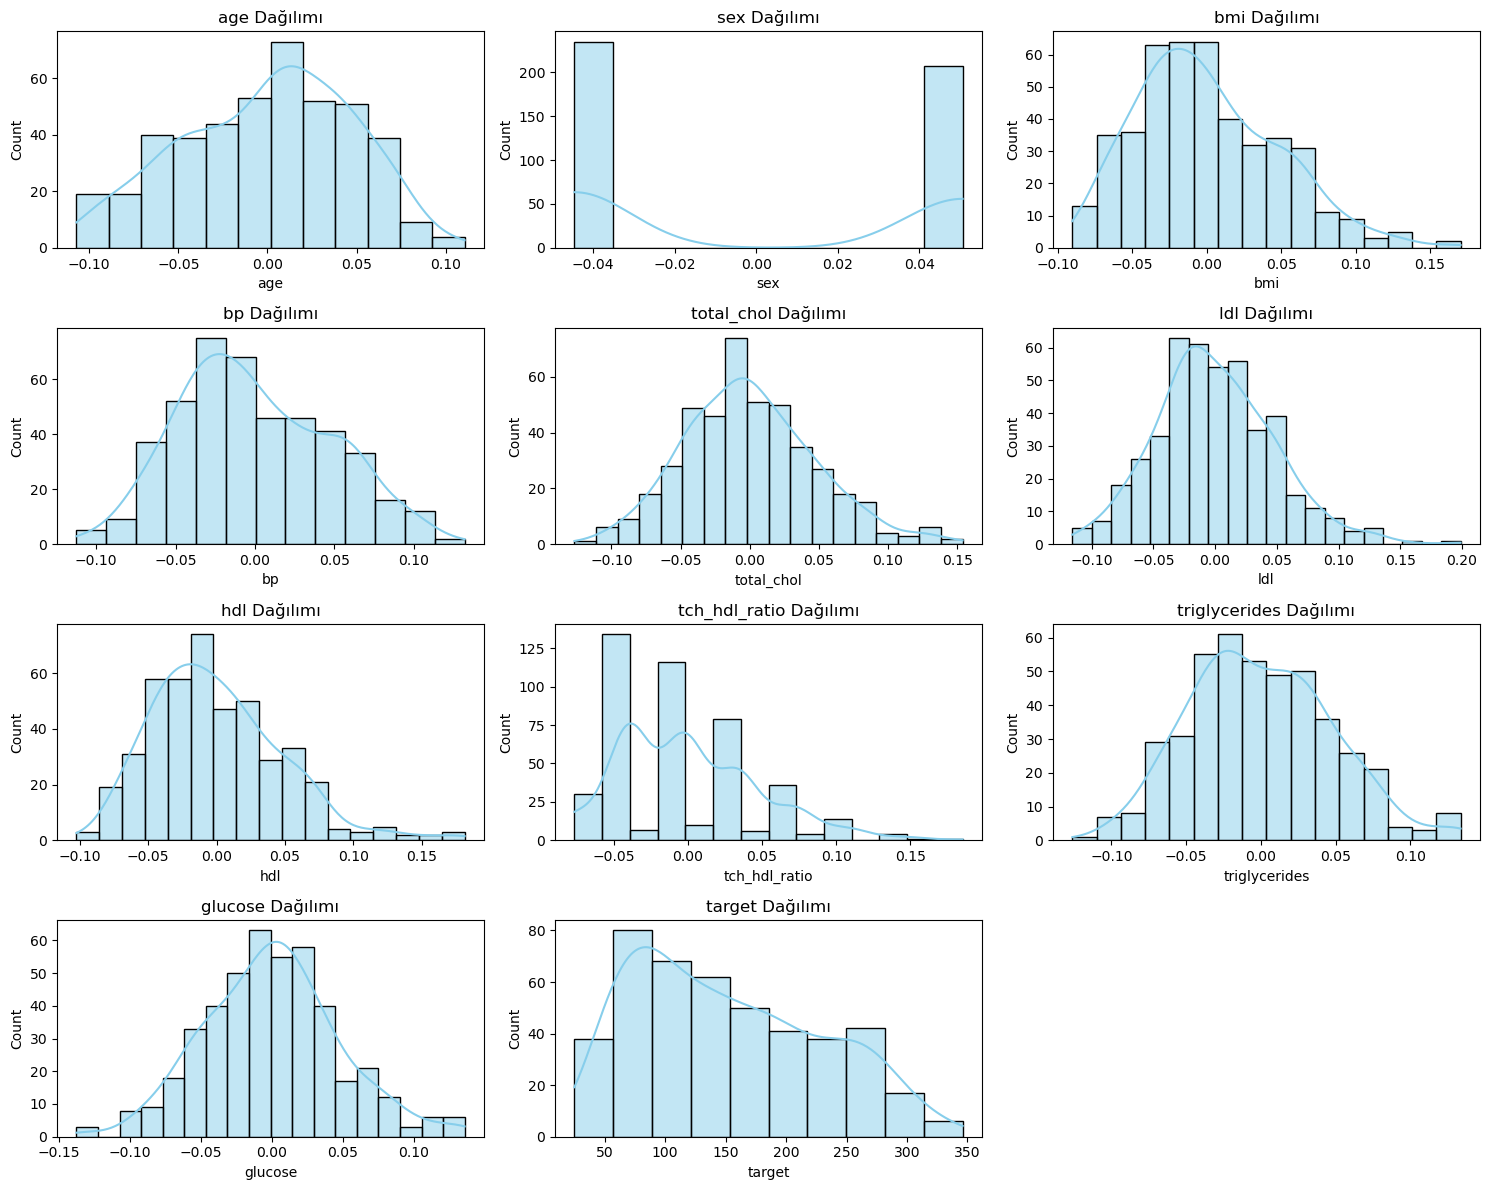

In [18]:
#  Histogramlar ile normal dağılımı hakkında fikir alacağım
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns):  #enumarate döngüde kolonun hangi sırada olacağınıda veriyor
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'{col} Dağılımı')
    plt.tight_layout()

plt.show()   #sex nominal normalde ama oda floata döndürüldüğü için buraya dahil edildi 

In [20]:
#normalliği gösterme yollarından birisi shapirowilk testi
normallik_ozet = df.apply(lambda x: shapiro(x)[1]) # apply ile df deki her değişkene uygulayacak, lambda ise fonksiyon tanımlamadan shapirowilk yapacak

normallik_tablosu = pd.DataFrame({'p-değeri': normallik_ozet})  #tablo yapacak

print(normallik_tablosu)      #hepsi normal dağılıma uymuyor

               p-değeri
age             0.00003
sex             0.00000
bmi             0.00000
bp              0.00007
total_chol      0.00513
ldl             0.00131
hdl             0.00000
tch_hdl_ratio   0.00000
triglycerides   0.00956
glucose         0.04095
target          0.00000


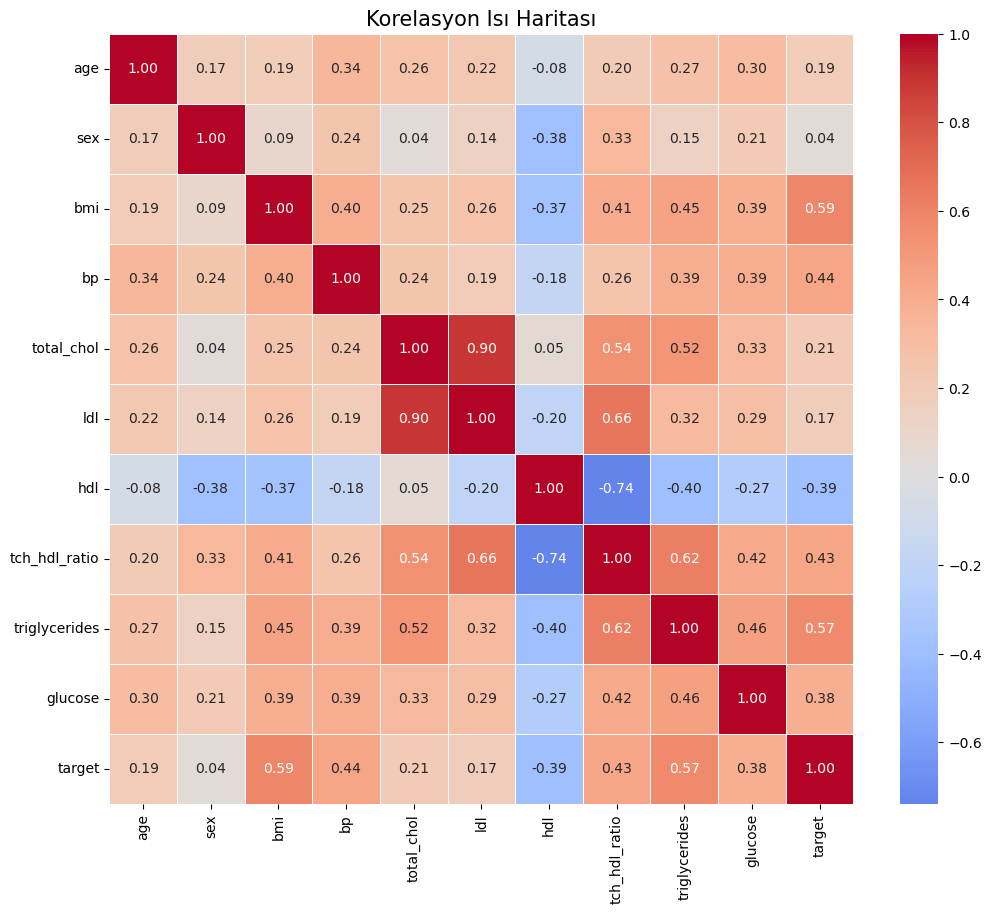

In [22]:
#corelasyon yapacağız aradaki ilişkileri görmek için heatmap ile bakacağız
corr_matrix = df.corr() #korelasyon 

plt.figure(figsize=(12, 10)) # grafik cizdireceğiz boyutunu belirtik
sns.heatmap(corr_matrix, 
            annot=True,      #kutuların içine sayısal değerleri yazılacak
            fmt=".2f",       # virgülden sonra 2 basamak 
            cmap='coolwarm', # renk paleti 
            linewidths=0.5,  # kutular arasına ince çizgi çek
            center=0)        # renk skalasının merkezini 0 yap

plt.title('Korelasyon Isı Haritası', fontsize=15)
plt.show()
